# ML-08 — Simple Models and Validation-Only Selection

This notebook compares the frozen transparent baseline, standardized logistic regression, and a constrained random forest. Models train on September 2025–March 2026 anchors and are compared on the identical April→May validation population. The May→June sealed labels are neither loaded nor evaluated.

## 1. Method and split

Numeric missing values are median-imputed with missingness indicators; logistic inputs are standardized. Content type is imputed and one-hot encoded. IDs, time-split context, coverage-only fields, and all future/outcome columns are excluded. The selection rule prefers logistic regression if it beats baseline Precision@50 without below-base-rate behavior at K=25, 50, or 100; otherwise it considers the random forest, then retains the baseline.

In [1]:
from pathlib import Path
import json
import sys

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score

ROOT = Path.cwd().resolve()
while not (ROOT / 'work' / 'scripts').exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from work.scripts.refresh_capstone import MODEL_FEATURES, baseline_score, build_candidate_pipelines, precision_at_k

cache = ROOT / 'work' / 'outputs' / 'model_examples.parquet'
con = duckdb.connect()
development = con.execute("SELECT * FROM read_parquet(?) WHERE month BETWEEN DATE '2025-09-01' AND DATE '2026-04-01'", [str(cache)]).df()
train = development.loc[pd.to_datetime(development['month']).lt('2026-04-01')].copy()
validation = development.loc[pd.to_datetime(development['month']).eq('2026-04-01')].copy()
for frame in (train, validation):
    frame['content_type'] = frame['content_type'].fillna('unknown').astype(str)
forbidden = {'client_hash_id', 'content_hash_id', 'month', 'future_decline', 'outcome_impressions', 'outcome_month', 'outcome_gsc_available_days'}
assert forbidden.isdisjoint(MODEL_FEATURES)
assert train['month'].max() < validation['month'].min()
print(f'Training rows: {len(train):,}; validation rows: {len(validation):,}')
print(f'Training base rate: {train.future_decline.mean():.1%}; validation base rate: {validation.future_decline.mean():.1%}')
print('Predictive features:', ', '.join(MODEL_FEATURES))

mkdir -p failed for path C:\Users\hasan\AppData\Local\matplotlib: [WinError 5] Access is denied: 'C:\\Users\\hasan\\AppData\\Local\\matplotlib'


Matplotlib created a temporary cache directory at C:\Users\hasan\AppData\Local\Temp\matplotlib-tcbcsn4g because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Training rows: 341,546; validation rows: 93,474
Training base rate: 29.3%; validation base rate: 53.8%
Predictive features: impressions, clicks, ctr, prior_impressions, prior_clicks, impression_momentum, avg_position, position_available, content_age_days, search_volume, content_type


## 2. Fit candidates and compare on identical rows

Precision@50 is primary because a content team has limited review capacity. Average precision, Recall@50, and Lift@50 are supporting measures. All methods receive exactly the same validation rows and labels.

In [2]:
def metric_row(name, labels, scores):
    p50 = precision_at_k(labels, scores, 50)
    base = float(pd.Series(labels).mean())
    order = np.argsort(-np.asarray(scores), kind='stable')[:50]
    recall50 = float(np.asarray(labels)[order].sum() / np.asarray(labels).sum())
    return {
        'method': name, 'rows': int(len(labels)), 'precision_at_50': float(p50),
        'recall_at_50': recall50, 'lift_at_50': float(p50 / base),
        'average_precision': float(average_precision_score(labels, scores)),
        'precision_at_25': float(precision_at_k(labels, scores, 25)),
        'precision_at_100': float(precision_at_k(labels, scores, 100)),
    }

labels_train = train['future_decline'].astype(int)
labels_validation = validation['future_decline'].astype(int)
scores = {'fixed_baseline': baseline_score(validation)}
fitted = {}
for name, pipeline in build_candidate_pipelines(random_seed=42).items():
    pipeline.fit(train[list(MODEL_FEATURES)], labels_train)
    fitted[name] = pipeline
    scores[name] = pipeline.predict_proba(validation[list(MODEL_FEATURES)])[:, 1]
metrics = [metric_row(name, labels_validation, method_scores) for name, method_scores in scores.items()]
metrics_frame = pd.DataFrame(metrics).set_index('method')
assert metrics_frame['rows'].nunique() == 1
display(metrics_frame)

,rows,precision_at_50,recall_at_50,lift_at_50,average_precision,precision_at_25,precision_at_100
method,,,,,,,
fixed_baseline,93474,0.66,0.000656,1.226888,0.533356,0.68,0.58
logistic_regression,93474,0.40,0.000398,0.743569,0.529383,0.40,0.54
random_forest,93474,0.54,0.000537,1.003818,0.604166,0.48,0.57


## 3. Selection and Precision-at-K stability

The rule is applied exactly as stated, with no sealed result available. The chart shows performance across several review capacities so a single lucky cutoff is visible rather than hidden.

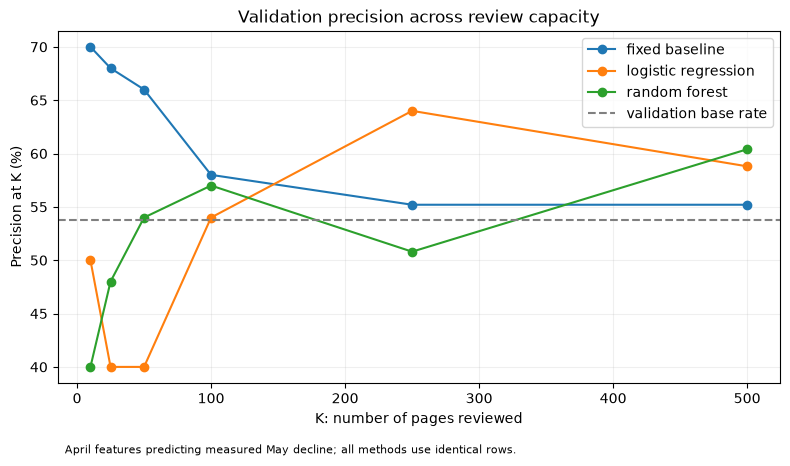

Selected method: fixed_baseline; validation Precision@50: 66.0%


In [3]:
base_rate = float(labels_validation.mean())
baseline_p50 = metrics_frame.loc['fixed_baseline', 'precision_at_50']
def stable(name):
    return all(metrics_frame.loc[name, col] > base_rate for col in ['precision_at_25', 'precision_at_50', 'precision_at_100'])
if metrics_frame.loc['logistic_regression', 'precision_at_50'] > baseline_p50 and stable('logistic_regression'):
    selected = 'logistic_regression'
elif metrics_frame.loc['random_forest', 'precision_at_50'] > baseline_p50 and stable('random_forest'):
    selected = 'random_forest'
else:
    selected = 'fixed_baseline'
ks = [10, 25, 50, 100, 250, 500]
precision_curves = {name: [precision_at_k(labels_validation, method_scores, k) for k in ks] for name, method_scores in scores.items()}
fig, ax = plt.subplots(figsize=(8, 4.8))
for name, values in precision_curves.items():
    ax.plot(ks, [100*x for x in values], marker='o', label=name.replace('_', ' '))
ax.axhline(100*base_rate, linestyle='--', color='gray', label='validation base rate')
ax.set(title='Validation precision across review capacity', xlabel='K: number of pages reviewed', ylabel='Precision at K (%)')
ax.legend()
ax.grid(alpha=.2)
ax.text(.01, -.20, 'April features predicting measured May decline; all methods use identical rows.', transform=ax.transAxes, fontsize=8)
fig.tight_layout()
figure_path = ROOT / 'work' / 'figures' / 'validation_precision_at_k.png'
fig.savefig(figure_path, dpi=180, bbox_inches='tight')
plt.show()
receipt = {
    'training_window': '2025-09 through 2026-03', 'validation_window': '2026-04 predicting 2026-05',
    'training_rows': int(len(train)), 'validation_rows': int(len(validation)),
    'validation_positive_rate': base_rate, 'primary_metric': 'precision_at_50',
    'selection_rule': 'prefer logistic if it beats baseline P@50 and P@25/P@50/P@100 all exceed base rate; otherwise consider random forest, then baseline',
    'selected_method': selected, 'feature_columns': list(MODEL_FEATURES),
    'candidates': metrics, 'identical_validation_rows': True, 'sealed_month_used': False, 'random_seed': 42,
}
(ROOT / 'work' / 'outputs' / 'model_selection.json').write_text(json.dumps(receipt, indent=2) + '\n', encoding='utf-8')
print(f'Selected method: {selected}; validation Precision@50: {metrics_frame.loc[selected, "precision_at_50"]:.1%}')

## 4. Representative validation errors

False positives consume review capacity; false negatives are missed decline opportunities. The sample below contains safe feature values only and is used to understand limitations, not to retune against the sealed month.

In [4]:
selected_scores = np.asarray(scores[selected])
ranked_index = np.argsort(-selected_scores, kind='stable')
analysis = validation.reset_index(drop=True).copy()
analysis['score'] = selected_scores
analysis['predicted_high_risk'] = analysis.index.isin(ranked_index[:50])
false_positives = analysis.loc[analysis['predicted_high_risk'] & analysis['future_decline'].eq(0)].head(5)
false_negatives = analysis.loc[~analysis['predicted_high_risk'] & analysis['future_decline'].eq(1)].sort_values('score').head(5)
safe_columns = ['score', 'impressions', 'impression_momentum', 'avg_position', 'content_age_days', 'ctr', 'content_type']
print(f'False positives in top 50: {int((analysis.predicted_high_risk & analysis.future_decline.eq(0)).sum())}; positives outside top 50: {int((~analysis.predicted_high_risk & analysis.future_decline.eq(1)).sum())}')
display(pd.concat({'false_positive_examples': false_positives[safe_columns], 'low_scored_positive_examples': false_negatives[safe_columns]}))
assert receipt['sealed_month_used'] is False
print('Selection is frozen from validation evidence only; the sealed May→June labels were not loaded.')

False positives in top 50: 17; positives outside top 50: 50251


score  impressions  \
false_positive_examples      6651   77.199640         3192   
                             37077  78.015946        10538   
                             37152  78.173925         2372   
                             48746  77.109096        35540   
                             61466  79.091243         8591   
low_scored_positive_examples 23324  17.657829          101   
                             17271  17.657829          101   
                             26114  17.691725          102   
                             6409   17.725294          103   
                             23375  17.758541          104   

                                    impression_momentum  avg_position  \
false_positive_examples      6651              0.327418     10.627820   
                             37077             0.232273      3.952458   
                             37152             0.125463      8.716273   
                             48746             0.565311      7.662634   
                             61466             0.280120      6.022116   
low_scored_positive_examples 23324                  NaN     20.490000   
                             17271                  NaN     34.170000   
                             26114                  NaN     30.653465   
                             6409                   NaN     51.715686   
                             23375                  NaN     29.776699   

                                    content_age_days       ctr  \
false_positive_examples      6651                358  0.001566   
                             37077               344  0.002752   
                             37152               296  0.001265   
                             48746               440  0.001604   
                             61466               442  0.000931   
low_scored_positive_examples 23324                29  0.000000   
                             17271                29  0.000000   
                             26114                29  0.009804   
                             6409                 29  0.000000   
                             23375                29  0.000000   

                                       content_type  
false_positive_examples      6651   keyword article  
                             37077  keyword article  
                             37152  keyword article  
                             48746  keyword article  
                             61466  keyword article  
low_scored_positive_examples 23324  keyword article  
                             17271  keyword article  
                             26114  keyword article  
                             6409   keyword article  
                             23375  keyword article

Selection is frozen from validation evidence only; the sealed May→June labels were not loaded.


## Self-check

- [x] Preprocessing is fit inside each training pipeline.
- [x] IDs, coverage-only fields, and outcome columns are excluded.
- [x] Baseline and candidates use identical validation rows.
- [x] Selection uses Precision@50 plus adjacent-K stability.
- [x] The sealed May→June outcome remains unopened.